<a href="https://colab.research.google.com/github/SohanKumar56/23102A0056_RPROGRAMMING/blob/main/Lab5_RProgramming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## R Network Analysis

This notebook will perform network analysis using R's `igraph` package.

In [20]:
# Install the igraph package (only needs to be run once per session)
install.packages("igraph")

# Load the library into your environment
library(igraph)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




Now, let's load the `igraph` library, read the data, and create the network graph.

In [22]:
data <- read.csv('/content/networkdata.csv', header=TRUE)
y <- data.frame(data$first, data$second)

# Create network using the recommended function
net <- graph_from_data_frame(y, directed=TRUE)
V(net)$label <- V(net)$name
V(net)$degree <- degree(net)

Let's visualize the distribution of node degrees using a histogram.

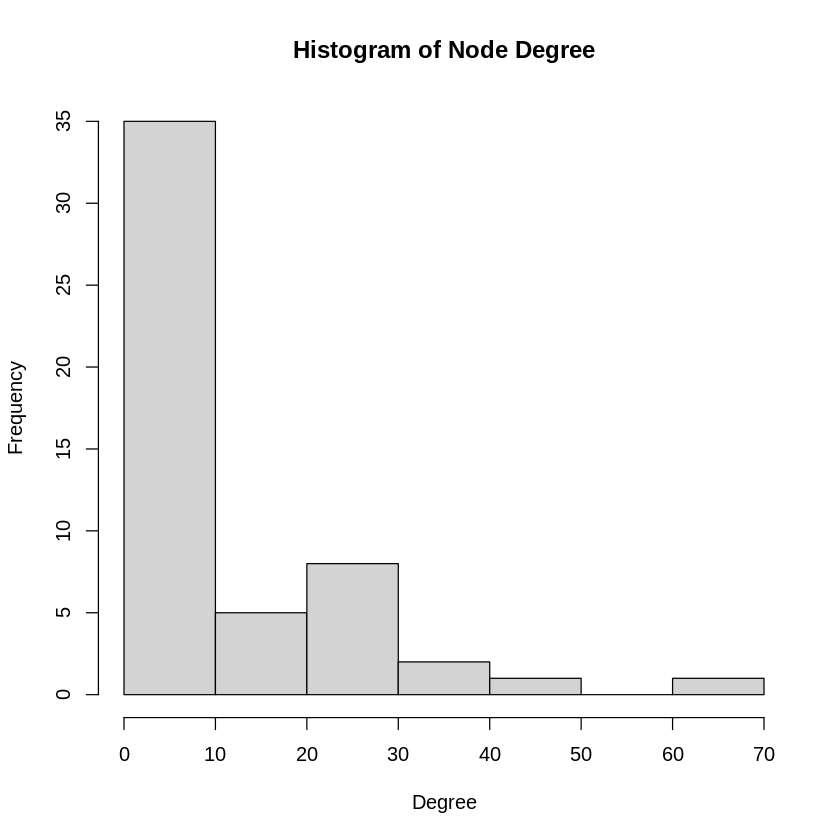

In [23]:
# Histogram of node degree
hist(V(net)$degree, main='Histogram of Node Degree', xlab='Degree')

Now, let's plot the basic network diagram.

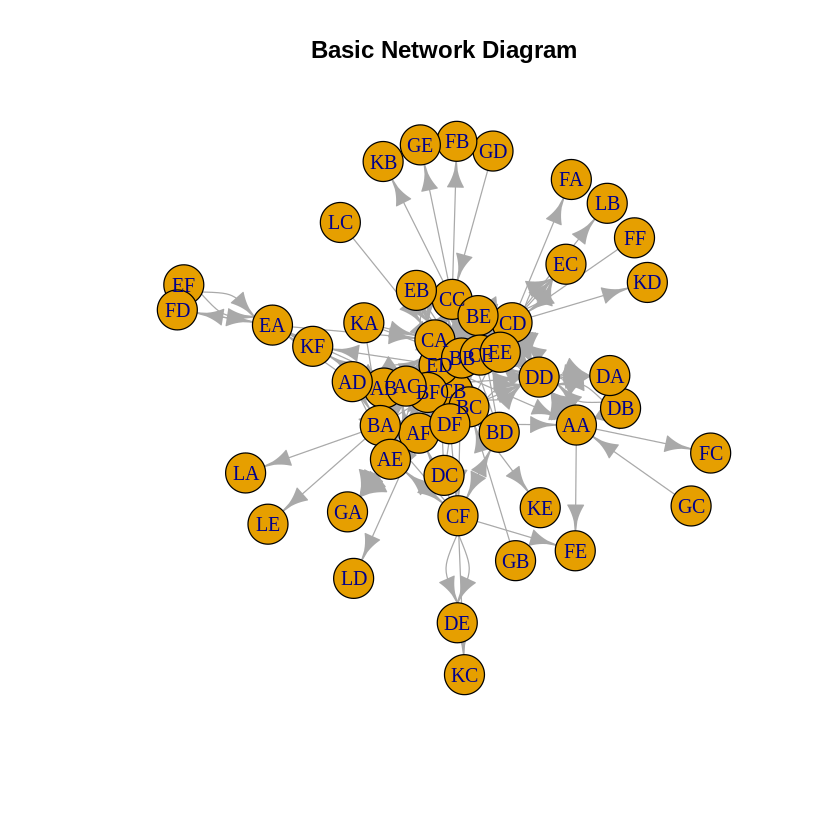

In [24]:
# Network diagram
plot(net, main='Basic Network Diagram')

Here's a more advanced plot highlighting node degrees and using a different layout.

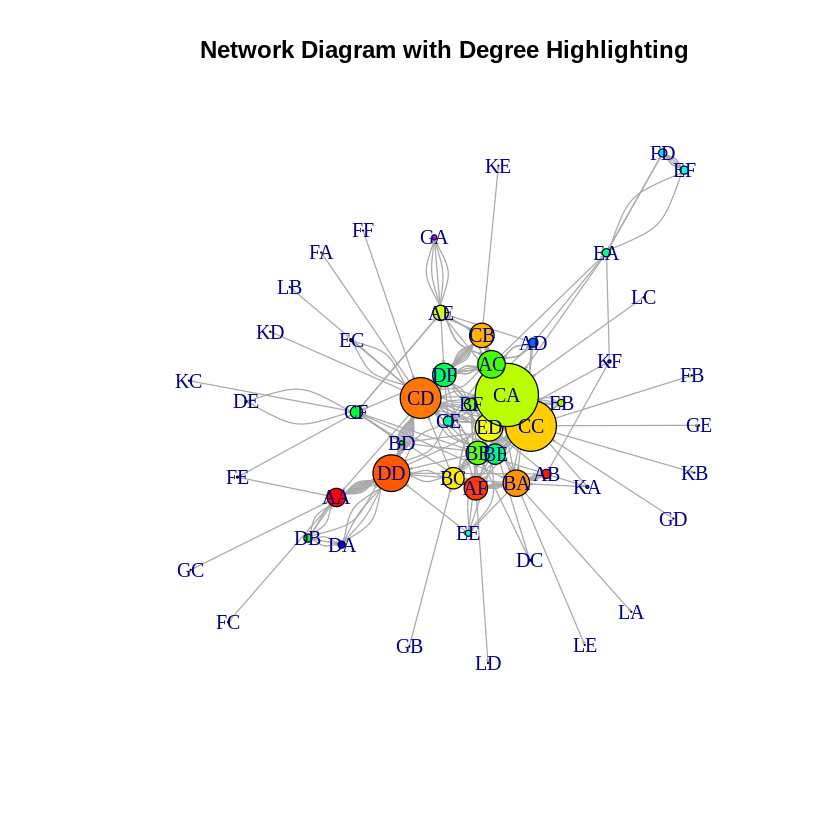

In [25]:
# Highlighting degrees & layouts
plot(net,
     vertex.color = rainbow(vcount(net)), # Use vcount(net) for consistent coloring
     vertex.size = V(net)$degree*0.4,
     edge.arrow.size = 0.1,
     layout=layout.fruchterman.reingold,
     main='Network Diagram with Degree Highlighting')

Next, we'll calculate and visualize hub and authority scores for the network.

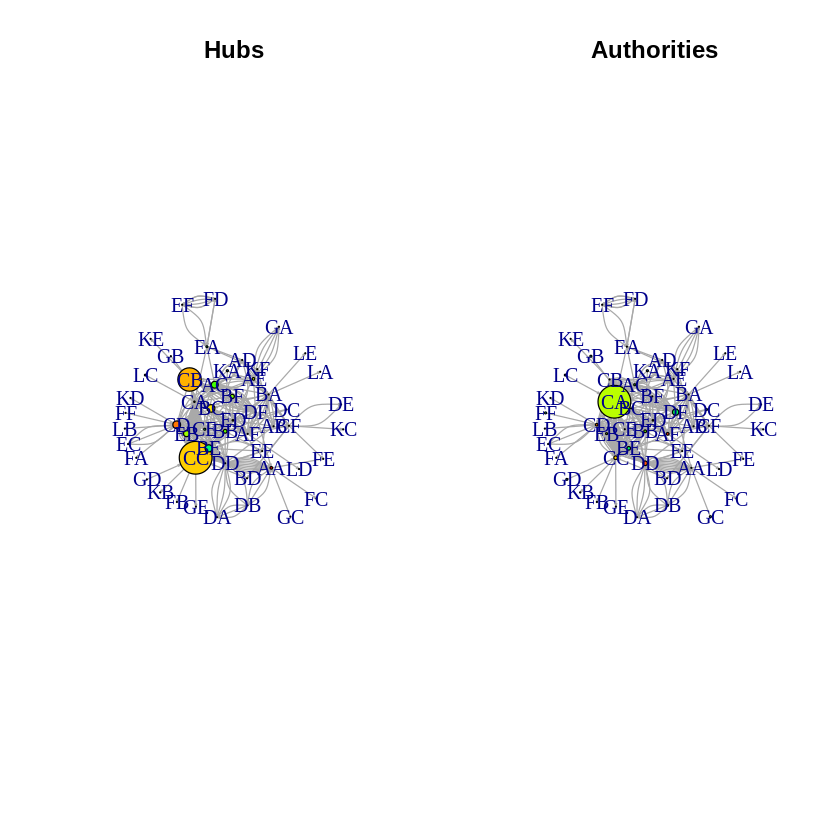

In [29]:
# Hub and authorities
hs <- hub_score(net)$vector
as <- authority.score(net)$vector

par(mfrow=c(1,2)) # Set up a 1x2 plot layout
set.seed(123)
plot(net,
     vertex.size=hs*30,
     main = 'Hubs',
     vertex.color = rainbow(vcount(net)),
     edge.arrow.size=0.1,
     layout = layout.kamada.kawai)

plot(net,
     vertex.size=as*30,
     main = 'Authorities',
     vertex.color = rainbow(vcount(net)),
     edge.arrow.size=0.1,
     layout = layout.kamada.kawai)
par(mfrow=c(1,1)) # Reset plot layout

Finally, let's perform community detection using the edge-betweenness algorithm on an undirected version of the network and visualize the detected communities.

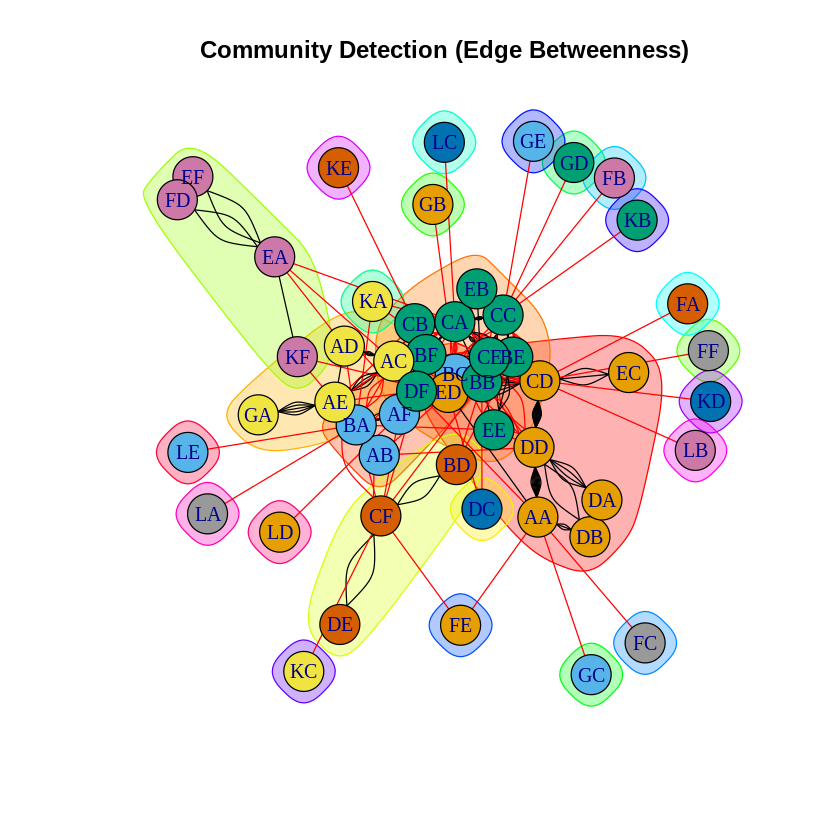

In [27]:
# Community detection
net_undirected <- graph.data.frame(y, directed = FALSE) # Create undirected graph for community detection
cnet <- cluster_edge_betweenness(net_undirected)
plot(cnet, net_undirected, main='Community Detection (Edge Betweenness)') # Pass the graph to plot alongside communities